<a href="https://colab.research.google.com/github/tewei0328/teach-programming/blob/main/twtalk5_gem_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import datetime

# --- 1. 配置區：台股 ETF 觀察清單 ---
WATCHLIST = {
    "0050.TW": "元大台灣50",
    "0051.TW": "元大中型100",
    "0053.TW": "元大電子",
    "0056.TW": "元大高股息",
    "006203.TW": "元大MSCI台灣",
    "006204.TW": "永豐臺灣加權",
    "00713.TW": "元大台灣高息低波",
    "00728.TW": "第一金工業30",
    "00733.TW": "富邦臺灣中小",
    "00878.TW": "國泰永續高股息",
    "00881.TW": "國泰台灣5G+",
    "00891.TW": "中信關鍵半導體",
    "00894.TW": "中信小資高價30",
    "00900.TW": "富邦特選高股息30",
    "00901.TW": "永豐智能車供應鏈",
    "00904.TW": "新光臺灣半導體30",
    "00905.TW": "FT臺灣Smart高股息",
    "00919.TW": "群益台灣精選高息",
    "00929.TW": "復華台灣科技優息",
    "00935.TW": "野村臺灣創新細分",
    "00947.TW": "台新臺灣IC設計",
    "00981A.TW": "中信成長高股息",
    "00936.TW": "台新永續高息中小型",
    "00939.TW": "統一台灣高息動能",
    "00940.TW": "元大台灣價值高息",
    "00941.TW": "中信上游半導體",
    "00946.TW": "群益科技高息成長",
    "00992A.TW": "中信臺灣智慧半導體",
    "00991A.TW": "中信高股息",
    "00922.TW": "國泰智能電動車",
    "00896.TW": "中信綠能及電動車",
    "0052.TW": "富邦科技",
    "00923.TW": "群益半導體收益",
    "00735.TW": "國泰中國A50",
    "00663L.TW": "國泰臺灣加權正2",
    "00830.TW": "富邦台灣ETF",
    "00670L.TW": "富邦臺灣加權正2",
    "00917.TW": "中信ESG永續高股息",
    "00927.TW": "群益台灣科技高息成長",
    "00902.TW": "中信臺灣智慧高股息",
    "00690.TW": "富邦印度ETF",
    "00980A.TW": "凱基台灣優選高股息30",
    "00982A.TW": "復華台灣科技高息",
    "00983A.TW": "富邦台灣優質高息",
    "00984A.TW": "統一台灣高息動能",
    "00985A.TW": "元大台灣高息低波",
    "00986A.TW": "國泰永續高股息",
    "00990A.TW": "群益台灣精選高息",
    "2330.TW": "台積電",
    "2344.TW": "華邦電",
    "2408.TW": "南亞科",
    "2881.TW": "富邦金",
    "2882.TW": "國泰金",
    "2883.TW": "開發金",
    "2884.TW": "玉山金",
    "2885.TW": "元大金",
    "2886.TW": "兆豐金",
    "2891.TW": "中信金"
}

def analyze_logic(ticker, df):
    """核心量化引擎：判定型態、籌碼、評分與建議"""
    last = df.iloc[-1]
    prev = df.iloc[-2]

    # A. 計算 20日主力成本 (VWMA)
    # 公式：(Close * Volume).rolling(20).sum() / Volume.rolling(20).sum()
    df['PV'] = df['Close'] * df['Volume']
    curr_vwma = df['PV'].rolling(20).sum() / df['Volume'].rolling(20).sum()
    curr_vwma_val = curr_vwma.iloc[-1]

    # B. 技術指標計算
    bias_pct = ((last['Close'] / curr_vwma_val) - 1) * 100
    day1_ret = (last['Close'] / prev['Close'] - 1) * 100
    day5_ret = (last['Close'] / df['Close'].iloc[-5] - 1) * 100
    m1_ret = (last['Close'] / df['Close'].iloc[-20] - 1) * 100
    vol_ratio = last['Volume'] / df['Volume'].rolling(5).mean().iloc[-1]

    # C. K棒型態判定
    body_pct = (last['Close'] - last['Open']) / last['Open']
    if last['High'] == last['Low']: k_type = "一字線"
    elif body_pct > 0.03: k_type = "帶量長紅"
    elif bias_pct > 0 and last['Close'] > curr_vwma_val: k_type = "VWMA回測守穩"
    else: k_type = "一般"

    # D. 籌碼動向判定 (量價邏輯)
    if day1_ret > 0.5 and vol_ratio > 1.2: chip = "籌碼集中 (量價齊揚)"
    elif day1_ret > 0 and vol_ratio < 0.6: chip = "籌碼鎖定 (惜售) 🔒"
    elif day1_ret < -0.5 and vol_ratio > 1.2: chip = "價量背離 (虛漲) ⚠️"
    else: chip = "籌碼中性 (多頭整理)"

    # E. 複合評分系統 (0-20分)
    score = 10
    if last['Close'] > curr_vwma_val: score += 5  # 趨勢強度
    if vol_ratio > 1.2: score += 3              # 成交動能
    if day1_ret > 1.5: score += 2               # 短線爆發
    if bias_pct > 10: score = 20                # 絕對過熱 (ETF門檻較個股低)

    # F. 決策建議
    if score >= 18:
        tag = "🚀 極致飆股 (過熱)" if bias_pct > 8 else "🚀 極致飆股"
        risk = "⚠️ 極高 (過熱)" if bias_pct > 8 else "✅ 穩健 (蓄勢)"
        advice = "💰 分批停利" if bias_pct > 8 else "持股續抱"
    elif score >= 12:
        tag = "📈 強勢多頭"
        risk = "✅ 穩健"
        advice = "持股續抱"
    else:
        tag = "📉 破線轉弱"
        risk = "📉 趨勢破壞"
        advice = "❌ 觸及停損"

    return {
        "Score": score, "股性標籤": tag, "K棒": k_type,
        "風險評級": risk, "籌碼動向": chip, "量比": round(vol_ratio, 2),
        "建議": advice, "代碼": ticker, "名稱": WATCHLIST.get(ticker),
        "收盤": round(last['Close'], 2), "VWMA": round(curr_vwma_val, 2),
        "乖離%": round(bias_pct, 2), "1D%": round(day1_ret, 2),
        "5D%": round(day5_ret, 2)
    }

def run_report():
    results = []
    print(f"📊 正在生成 {datetime.now().strftime('%Y-%m-%d')} 台股 ETF 量化報告...")

    for ticker in tqdm(WATCHLIST.keys()):
        try:
            stock = yf.Ticker(ticker)
            df = stock.history(period="3mo")
            if len(df) < 20: continue
            results.append(analyze_logic(ticker, df))
        except Exception as e:
            print(f"跳過 {ticker}: {e}")

    final_df = pd.DataFrame(results).sort_values("Score", ascending=False)

    # 存檔
    file_name = f"ETF_Report_{datetime.now().strftime('%Y%m%d')}.csv"
    final_df.to_csv(file_name, index=False, encoding="utf_8_sig")

    # 終端機顯示關鍵摘要
    print("\n" + "="*100)
    display_cols = ['Score', '股性標籤', '籌碼動向', '代碼', '名稱', '收盤', '乖離%', '建議']
    print(final_df[display_cols].to_string(index=False))
    print("="*100)
    print(f"\n✅ 報告已存檔：{file_name}")

if __name__ == "__main__":
    run_report()

📊 正在生成 2026-03-26 台股 ETF 量化報告...


100%|██████████| 58/58 [00:13<00:00,  4.19it/s]



 Score   股性標籤         籌碼動向        代碼           名稱      收盤    乖離%     建議
    18 🚀 極致飆股 價量背離 (虛漲) ⚠️  00941.TW      中信上游半導體   22.11   1.95   持股續抱
    18 🚀 極致飆股 價量背離 (虛漲) ⚠️  00901.TW     永豐智能車供應鏈   29.99   0.79   持股續抱
    15 📈 強勢多頭  籌碼中性 (多頭整理)  00733.TW       富邦臺灣中小   56.05   0.34   持股續抱
    15 📈 強勢多頭  籌碼中性 (多頭整理)   0056.TW        元大高股息   38.56   0.18   持股續抱
    15 📈 強勢多頭  籌碼中性 (多頭整理) 006204.TW       永豐臺灣加權  171.35   0.21   持股續抱
    15 📈 強勢多頭  籌碼鎖定 (惜售) 🔒  00728.TW      第一金工業30   45.00   3.53   持股續抱
    15 📈 強勢多頭  籌碼中性 (多頭整理)  00881.TW      國泰台灣5G+   37.26   2.02   持股續抱
    15 📈 強勢多頭  籌碼中性 (多頭整理)  00894.TW     中信小資高價30   34.64   4.86   持股續抱
    15 📈 強勢多頭  籌碼中性 (多頭整理)   0051.TW      元大中型100  110.30   1.80   持股續抱
    15 📈 強勢多頭  籌碼鎖定 (惜售) 🔒   0053.TW         元大電子  170.95   0.94   持股續抱
    15 📈 強勢多頭  籌碼中性 (多頭整理)  00936.TW    台新永續高息中小型   17.78   0.66   持股續抱
    15 📈 強勢多頭  籌碼中性 (多頭整理) 00981A.TW      中信成長高股息   20.92   6.31   持股續抱
    15 📈 強勢多頭  籌碼中性 (多頭整理)  00935.TW     野村臺灣創新細分   38.00   2.4

這套量化程式中的 **Score（總分）計算邏輯**，白話來說就像是一份**「股票強勢程度的健康檢查表」**。它將複雜的量價數據轉換成一個 0 到 20 分的數字，讓投資人一眼就能看出這檔股票目前是處於「蓄勢待發」、「強勢噴發」還是「過熱轉弱」的狀態。

以下是這套評分系統的底層邏輯拆解：

### 1. 基礎分：10 分 (起跑線)
每支進入掃描清單的股票，只要數據完整（超過 20 筆資料），一律先給 **10 分** 作為基準點。

### 2. 趨勢加分：+5 分 (站穩成本線)
*   **邏輯**：檢查收盤價是否高於 **20 日主力成本線 (VWMA)**。
*   **白話解釋**：**「趨勢對了就及格。」** 如果股價站在過去一個月大家的平均買進成本之上，代表多頭佔優勢，這是一個強力的趨勢支撐訊號。

### 3. 人氣加分：+3 分 (量能爆發)
*   **邏輯**：檢查**量比**是否大於 **1.2**。
*   **白話解釋**：**「有人氣才有戲。」** 當今天的成交量比過去 5 天的平均量多了 20% 以上，代表資金正在湧入，這檔股票被市場「驚醒」了。這呼應了因子庫中「無量變有量」的投資智慧。

### 4. 攻擊加分：+2 分 (短線爆發力)
*   **邏輯**：檢查 **1 天漲跌幅 (1D%)** 是否大於 **2%**。
*   **白話解釋**：**「動能展現。」** 單日漲幅超過 2%，代表多方今天出手的力道很果斷，具備短線攻擊的態勢。

### 5. 特殊狀態：直接給 20 分 (絕對過熱)
*   **邏輯**：當**乖離率 (bias_pct)** 超過 **18%**。
*   **白話解釋**：**「極致飆股模式。」** 當股價跑得比平均成本快太多（超過 18%），代表這是一檔超級飆股。系統會直接給滿分 20 分，但也因為太強了，系統會同步掛上「過熱」的標籤，提醒你要注意分批停利，不要盲目追高。

---

### 總結：分數如何決定你的行動？
程式計算出總分後，會自動把股票貼上三個標籤，作為你的操作指南：

*   **🚀 極致飆股 (18分以上)**：這標的強到沒朋友。如果乖離率還沒過高，就是續抱；如果超過 15%，就要考慮**分批停利**。
*   **📈 強勢多頭 (12~17分)**：屬於穩健上攻型，趨勢與量能都在水準之上，建議**持股續抱**。
*   **📉 破線轉弱 (12分以下)**：分數不及格，代表趨勢可能已經破位或動能消失，建議**觸及停損**。

這套邏輯的核心在於**「權重分配」**：它給予「趨勢 (+5)」最高的加分權重，確保你選出的股票不是亂漲，而是有底氣的多頭排列。

Fetching historical data for 22 selected ETFs/stocks for period: 1m...


/tmp/ipykernel_237/4073458900.py:55: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date, progress=False)
/tmp/ipykernel_237/4073458900.py:55: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date, progress=False)
/tmp/ipykernel_237/4073458900.py:55: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date, progress=False)
/tmp/ipykernel_237/4073458900.py:55: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date, progress=False)
/tmp/ipykernel_237/4073458900.py:55: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date, progress=False)
/tmp/ipykernel_237/4073458900.py:55: Fut

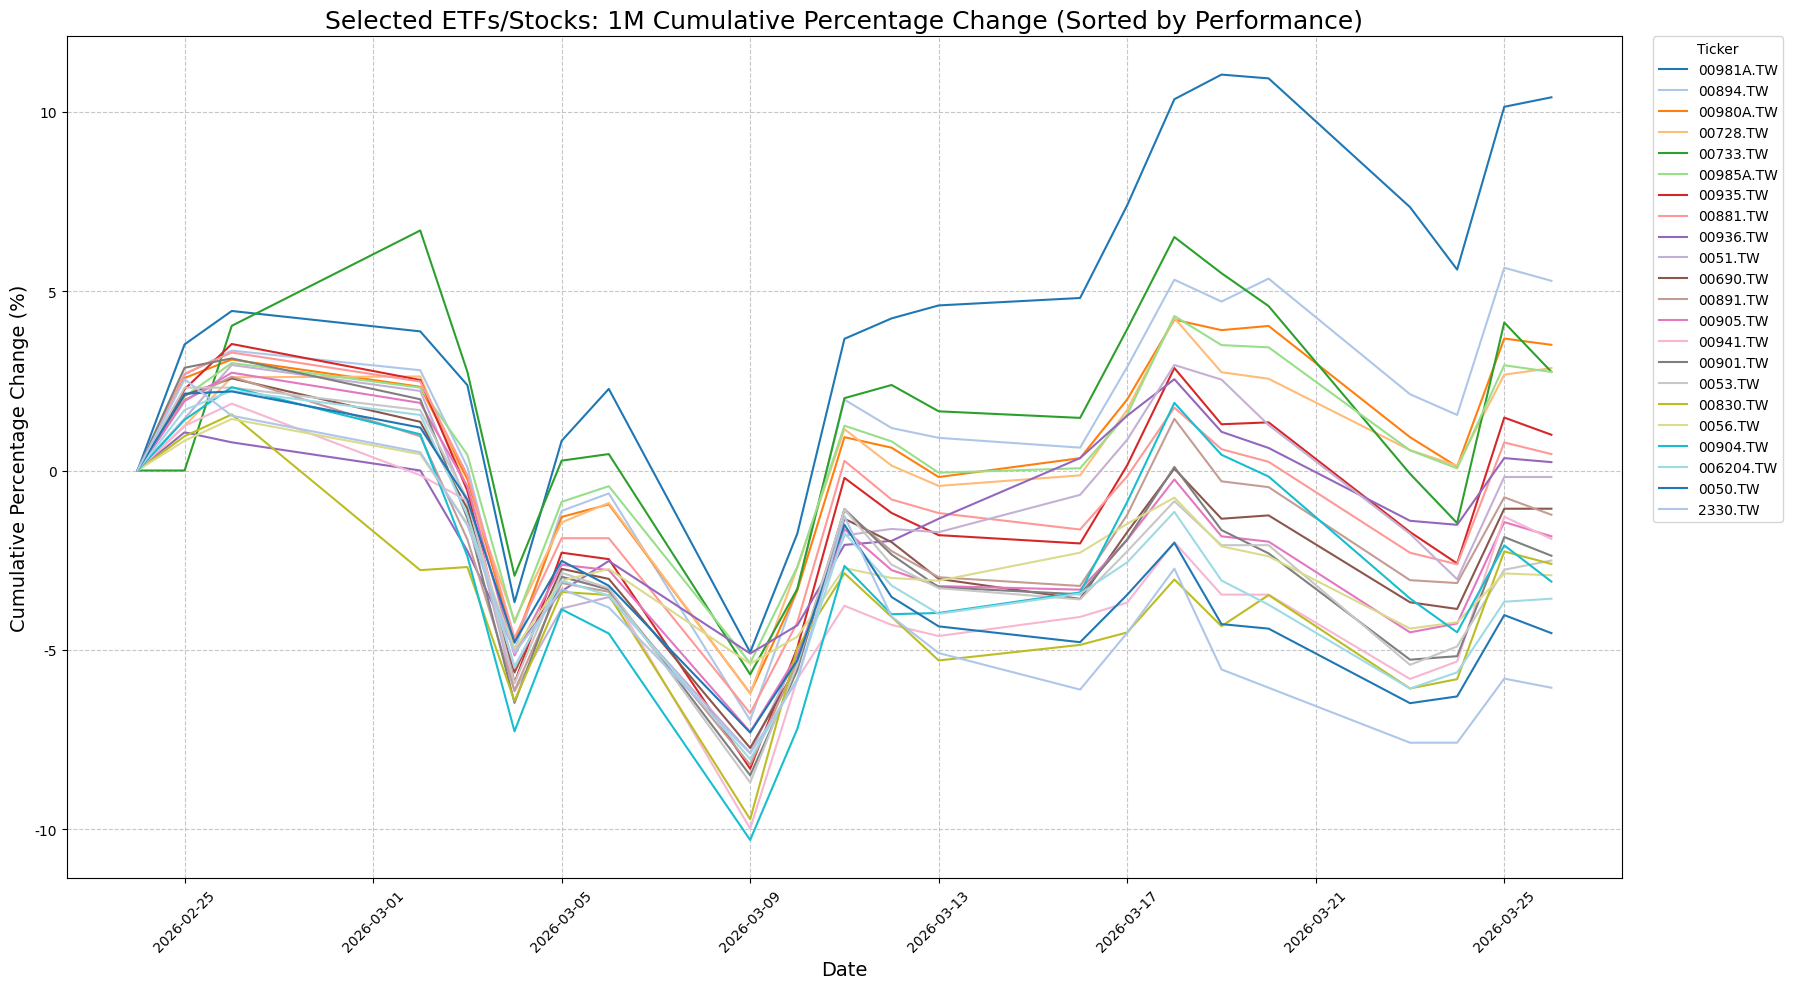

In [13]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# @param {type:"string"} [time_period='1m'] 允許的值: '1w', '1m', '3m', '6m'
time_period = "1m" # Default to 3 months

# Load the report generated previously
file_name = "ETF_Report_20260326.csv"
df_report = pd.read_csv(file_name)

# Sort by Score and get the top 20 ETFs (this forms the base list)
top_20_etfs = df_report.sort_values(by='Score', ascending=False).head(20)
current_top_tickers_set = set(top_20_etfs['代碼'].tolist())

# Add specific tickers requested by the user
additional_tickers = {'0050.TW', '2330.TW'}

# Combine the lists and ensure uniqueness
combined_tickers_set = current_top_tickers_set.union(additional_tickers)
top_20_tickers = list(combined_tickers_set)

# Re-create the names dictionary for all combined tickers
# Assuming WATCHLIST is defined in a previously executed cell and accessible
if 'WATCHLIST' not in globals():
    print("Warning: WATCHLIST not found. Ensure the initial setup cell is executed.")
    # Fallback if WATCHLIST is not defined (though it should be in this notebook)
    top_20_names = {ticker: ticker for ticker in top_20_tickers}
else:
    top_20_names = {ticker: WATCHLIST.get(ticker, ticker) for ticker in top_20_tickers}

print(f"Fetching historical data for {len(top_20_tickers)} selected ETFs/stocks for period: {time_period}...")

# Define date range based on time_period
end_date = datetime.now()
if time_period == '1w':
    start_date = end_date - timedelta(weeks=1)
elif time_period == '1m':
    start_date = end_date - timedelta(days=30)
elif time_period == '3m':
    start_date = end_date - timedelta(days=90)
elif time_period == '6m':
    start_date = end_date - timedelta(days=180)
else:
    print("Invalid time_period. Defaulting to 3 months.")
    start_date = end_date - timedelta(days=90)

# Fetch historical data and calculate cumulative percentage change
performance_data = pd.DataFrame()

for ticker in top_20_tickers:
    try:
        data = yf.download(ticker, start=start_date, end=end_date, progress=False)
        if not data.empty:
            # Ensure there is enough data for the chosen period
            if len(data) > 1:
                # Calculate cumulative percentage change from the first close price
                data['Cum_Pct_Change'] = (data['Close'] / data['Close'].iloc[0] - 1) * 100
                data['Ticker'] = ticker
                data['Name'] = top_20_names.get(ticker, ticker)
                performance_data = pd.concat([performance_data, data[['Cum_Pct_Change', 'Ticker', 'Name']]], ignore_index=False)
            else:
                print(f"Not enough data for {ticker} for the selected period.")
    except Exception as e:
        print(f"Could not download data for {ticker}: {e}")

# Reset index to make 'Date' a column again for plotting
performance_data = performance_data.reset_index()
performance_data = performance_data.rename(columns={'index': 'Date'})

# Calculate the last cumulative percentage change for each Ticker for sorting
latest_performance = performance_data.groupby('Ticker')['Cum_Pct_Change'].last().sort_values(ascending=False)
sorted_tickers = latest_performance.index.tolist()

# Plotting the performance
plt.figure(figsize=(18, 10))
sns.lineplot(data=performance_data, x='Date', y='Cum_Pct_Change', hue='Ticker', palette='tab20', hue_order=sorted_tickers)
plt.title(f'Selected ETFs/Stocks: {time_period.upper()} Cumulative Percentage Change (Sorted by Performance)', fontsize=18)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Cumulative Percentage Change (%)', fontsize=14)
plt.legend(title='Ticker', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()